# Othello-GPT learns a board

Can a transformer trained only to predict Othello moves recover the board internally? We use TDHook to read and edit the released Othello-GPT model, following [*Linear Latent World Models in Simple Transformers*](https://arxiv.org/abs/2310.07582).

We will look at three things: the board decoded from an activation, one targeted edit, and the full layer-by-game-length intervention pattern.

## Load the model and games

The model, linear probes, and 100 synthetic games are downloaded on first use and then cached locally.

In [1]:
from __future__ import annotations

import importlib.util
import sys
import types
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from huggingface_hub import hf_hub_download
from IPython.display import Markdown, display
from matplotlib.colors import ListedColormap
from torch.nn import functional as F
from transformer_lens import HookedTransformer, HookedTransformerConfig

from tdhook.interventions import (
    EarlyStoppingConfig,
    InterventionObjective,
    InterventionSpec,
    OptimizerConfig,
    optimize_intervention,
)
from tdhook.session import HookSession
from tdhook.targets import Target

OTHELLO_REVISION = "f23bb5696cf30b93bd8af8a391ee33fc3aac417e"
HF_REVISION = "905ca1a68b9f7dff77adc56af1962e5f6fcac274"
CACHE = Path.home() / ".cache" / "tdhook" / "othello-reproduction"
CACHE.mkdir(parents=True, exist_ok=True)
BASE = f"https://raw.githubusercontent.com/likenneth/othello_world/{OTHELLO_REVISION}"
ASSETS = {
    "main_linear_probe.pth": f"{BASE}/mechanistic_interpretability/main_linear_probe.pth",
    "board_seqs_int_small.npy": f"{BASE}/mechanistic_interpretability/board_seqs_int_small.npy",
    "board_seqs_string_small.npy": f"{BASE}/mechanistic_interpretability/board_seqs_string_small.npy",
    "othello.py": f"{BASE}/data/othello.py",
}


def fetch(name):
    path = CACHE / name
    if not path.exists():
        urllib.request.urlretrieve(ASSETS[name], path)
    return path


paths = {name: fetch(name) for name in ASSETS}
model_path = Path(
    hf_hub_download(
        repo_id="NeelNanda/Othello-GPT-Transformer-Lens",
        filename="synthetic_model.pth",
        revision=HF_REVISION,
        token=False,
    )
)

In [2]:
# The released simulator imports pgn only for championship-data utilities.
sys.modules.setdefault("pgn", types.ModuleType("pgn"))
spec = importlib.util.spec_from_file_location("released_othello", paths["othello.py"])
othello = importlib.util.module_from_spec(spec)
spec.loader.exec_module(othello)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cfg = HookedTransformerConfig(
    n_layers=8,
    d_model=512,
    d_head=64,
    n_heads=8,
    d_mlp=2048,
    d_vocab=61,
    n_ctx=59,
    act_fn="gelu",
    normalization_type="LNPre",
    device=str(device),
)
model = HookedTransformer(cfg)
model.load_state_dict(torch.load(model_path, map_location=device, weights_only=False))
model.eval()
probe = torch.load(paths["main_linear_probe.pth"], map_location=device, weights_only=False)
games_int = torch.from_numpy(np.load(paths["board_seqs_int_small.npy"])[:100, :59].astype(np.int64)).to(device)
games_string = np.load(paths["board_seqs_string_small.npy"])[:100, :59]

display(Markdown(f"**Ready:** 100 games · 8-layer model · `{device}`"))

**Ready:** 100 games · 8-layer model · `cuda`

## Decode the internal board

We capture the residual stream after layer 7 and apply the released linear probe. The example below compares the real board with the board decoded from a single activation.

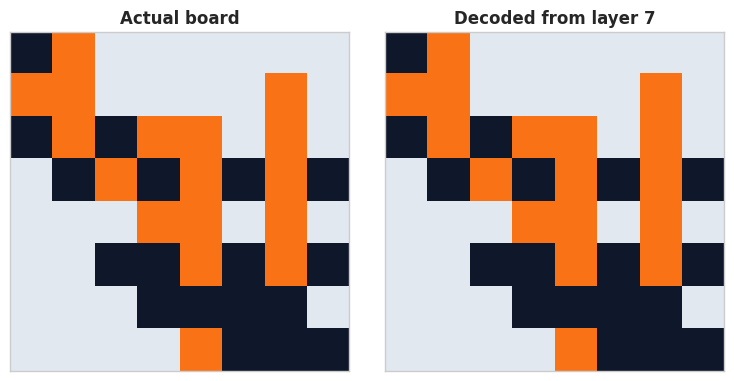

**99.28%** of board squares decoded correctly  ·  **99.93%** legal next moves across 5,800 positions

In [3]:
states = []
for sequence in games_string:
    board = othello.OthelloBoardState()
    sequence_states = []
    for move in sequence.tolist():
        board.umpire(int(move))
        sequence_states.append(board.state.copy())
    states.append(np.stack(sequence_states))
states = torch.from_numpy(np.stack(states))
labels = torch.empty(states.shape, dtype=torch.long)
labels[states == 0], labels[states == -1], labels[states == 1] = 0, 1, 2
labels = labels.to(device)

residual_target = Target("blocks.6.hook_resid_post", "activation", -1, tuple(range(512)))
with torch.inference_mode(), HookSession(model) as session:
    captured = session.capture(residual_target)
    logits = model(games_int)
    probe_logits = torch.einsum("bpd,mdrco->mbprco", captured.values[-1], probe)
probe_correct = probe_logits.argmax(-1) == labels.unsqueeze(0)

lo, hi = 5, 54
odd_accuracy = float(probe_correct[0, :, lo:hi:2].float().mean().cpu())
even_accuracy = float(probe_correct[1, :, lo + 1 : hi : 2].float().mean().cpu())
designated_accuracy = (odd_accuracy + even_accuracy) / 2

playable = [index for index in range(64) if index not in (27, 28, 35, 36)]
illegal = total = 0
predicted_tokens = logits.argmax(-1).cpu().numpy()
for game_index, sequence in enumerate(games_string):
    board = othello.OthelloBoardState()
    for position, move in enumerate(sequence.tolist()):
        board.umpire(int(move))
        if position < 58:
            token = int(predicted_tokens[game_index, position])
            predicted_square = -1 if token == 0 else playable[token - 1]
            illegal += int(predicted_square not in board.get_valid_moves())
            total += 1
legal_rate = 1 - illegal / total

game_index, position = 8, 30
probe_mode = 1 if position % 2 == 0 else 0
actual_board = labels[game_index, position].detach().cpu()
decoded_board = probe_logits[probe_mode, game_index, position].argmax(-1).detach().cpu()
cmap = ListedColormap(["#e2e8f0", "#0f172a", "#f97316"])

with plt.style.context("seaborn-v0_8-whitegrid"):
    figure, axes = plt.subplots(1, 2, figsize=(7.5, 3.7), constrained_layout=True)
    for axis, board, title in zip(axes, (actual_board, decoded_board), ("Actual board", "Decoded from layer 7")):
        axis.imshow(board, cmap=cmap, vmin=0, vmax=2)
        axis.set_title(title, fontweight="bold")
        axis.set_xticks([])
        axis.set_yticks([])
    plt.show()

display(
    Markdown(
        f"**{designated_accuracy:.2%}** of board squares decoded correctly  ·  "
        f"**{legal_rate:.2%}** legal next moves across {total:,} positions"
    )
)

## Edit one square

First we verify that TDHook and the original TransformerLens hook produce the same intervention. Then we optimize the activation until the probe reads the chosen square differently.

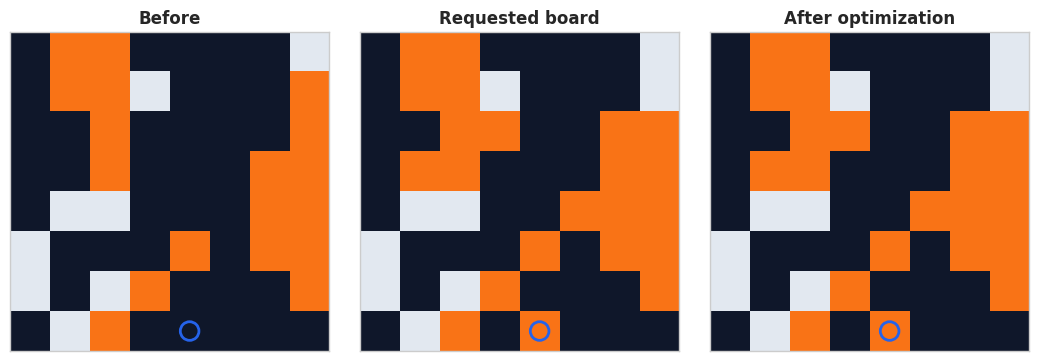

The optimized activation matches the requested board after **4 steps**. TDHook differs from the reference hook by only **0.0e+00** at most.

In [4]:
game = games_int[8:9, :51]
position, layer, row, column, scale = 50, 3, 7, 4, 4
direction = probe[0, :, row, column, 2] - probe[0, :, row, column, 1]
direction = direction / direction.norm()
position_target = Target(f"blocks.{layer}.hook_resid_post", "activation", -2, (position,))

with torch.inference_mode():
    with HookSession(model) as capture_session:
        activation = capture_session.capture(position_target)
        model(game)
    coefficient = (activation.values[-1] @ direction).unsqueeze(-1)
    replacement = activation.values[-1] - (scale + 1) * coefficient * direction
    with HookSession(model) as intervention_session:
        intervention_session.replace(position_target, replacement)
        tdhook_log_probs = model(game).log_softmax(-1)

    def reference_hook(residual, hook):
        coefficient = residual[0, position] @ direction
        residual[0, position] -= (scale + 1) * coefficient * direction

    reference_log_probs = model.run_with_hooks(
        game, fwd_hooks=[(f"blocks.{layer}.hook_resid_post", reference_hook)]
    ).log_softmax(-1)

max_abs_difference = float((tdhook_log_probs - reference_log_probs).abs().max().cpu())
probe_mode = 1 if position % 2 == 0 else 0
target_board = labels[8, position].clone()
target_board[row, column] = 1 if target_board[row, column] != 1 else 2


def probe_board_objective(_model_output, intervention):
    board_logits = torch.einsum("...d,drco->...rco", intervention, probe[probe_mode])
    desired = target_board.expand(*intervention.shape[:-1], 8, 8)
    probe_loss = F.cross_entropy(board_logits.flatten(0, -2), desired.flatten())
    return InterventionObjective(probe_loss, {"probe_cross_entropy": probe_loss})


optimized = optimize_intervention(
    model,
    (game,),
    InterventionSpec(
        position_target,
        probe_board_objective,
        "linear-probe board cross-entropy",
        max_steps=300,
        optimizer=OptimizerConfig("adam", 5e-2),
        early_stopping=EarlyStoppingConfig(objective_threshold=0.05, min_delta=1e-5, patience=30),
        preservation_regularizer=lambda value, reference: 1e-4 * (value - reference).square().mean(),
    ),
    seed=44,
)
optimized_value = optimized.interventions[0].value
with torch.inference_mode():
    before_board = torch.einsum("...d,drco->...rco", activation.values[-1], probe[probe_mode]).argmax(-1)[0, 0].cpu()
    optimized_board = torch.einsum("...d,drco->...rco", optimized_value, probe[probe_mode]).argmax(-1)[0, 0].cpu()

with plt.style.context("seaborn-v0_8-whitegrid"):
    figure, axes = plt.subplots(1, 3, figsize=(10.5, 3.5), constrained_layout=True)
    for axis, board, title in zip(
        axes,
        (before_board, target_board.cpu(), optimized_board),
        ("Before", "Requested board", "After optimization"),
    ):
        axis.imshow(board, cmap=cmap, vmin=0, vmax=2)
        axis.scatter(column, row, s=180, facecolors="none", edgecolors="#2563eb", linewidths=2)
        axis.set_title(title, fontweight="bold")
        axis.set_xticks([])
        axis.set_yticks([])
    plt.show()

display(
    Markdown(
        f"The optimized activation matches the requested board after "
        f"**{optimized.stages[0].steps_completed} steps**. TDHook differs from the reference hook by "
        f"only **{max_abs_difference:.1e}** at most."
    )
)

## Repeat the intervention across the model

Now we repeat the paper's intervention across 50 games, all eight layers, and several game lengths. The controls use the wrong layer, a randomized probe, or a no-op replacement.

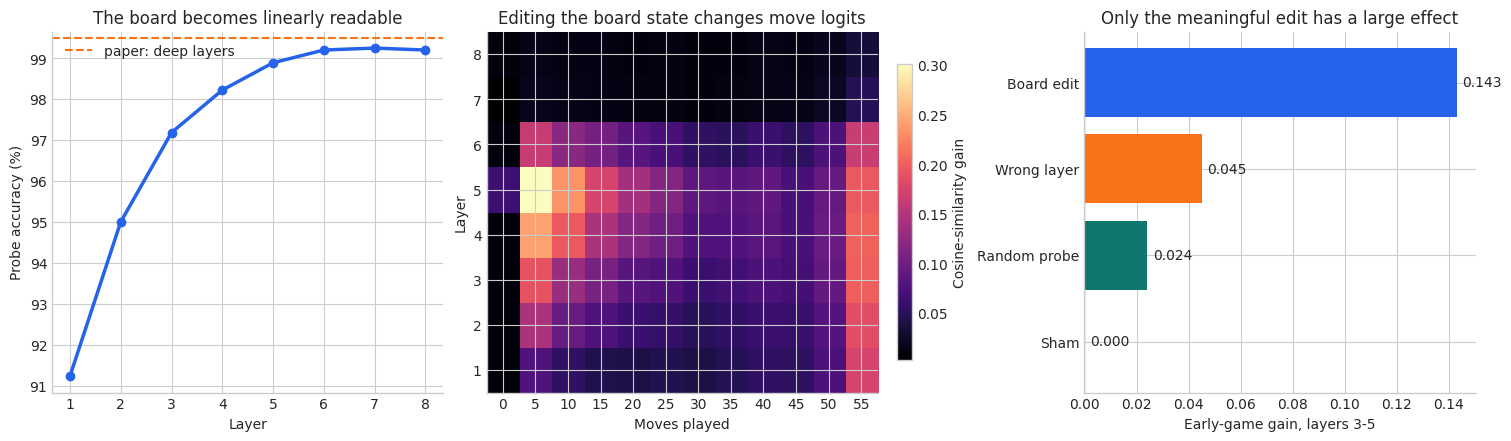

In the early game, editing middle layers has **0.130** more effect than editing late layers (95% bootstrap interval **0.125–0.136**).

In [5]:
from othello_figure4 import plot_figure4_reproduction, run_figure4_reproduction

figure4 = run_figure4_reproduction(
    cache=CACHE,
    games_int=games_int.detach().cpu().numpy(),
    games_string=games_string,
    othello=othello,
    number_games=50,
    seed=44,
)
plot_figure4_reproduction(figure4)
plt.show()

ordering = figure4["middle_over_late"]
lower, upper = ordering["interval"]
display(
    Markdown(
        f"In the early game, editing middle layers has **{ordering['mean']:.3f}** more "
        f"effect than editing late layers (95% bootstrap interval **{lower:.3f}–{upper:.3f}**)."
    )
)

## Takeaway

The model's residual stream contains a board representation that becomes sharply readable in later layers. Editing that representation changes move predictions most strongly in the middle of the network, while the sham and randomized controls stay near zero—the same qualitative pattern as Figure 4.